In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df=pd.read_csv(r"C:\Users\Sarvesh\Downloads\Fast Food Sales - Balaji Fast Food Sales.csv")


In [80]:
df.shape

(1000, 10)

In [81]:
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [83]:
df.describe()

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


In [84]:
df.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [85]:
df['date']

0      07-03-2022
1       8/23/2022
2      11/20/2022
3      02-03-2023
4      10-02-2022
          ...    
995     3/19/2023
996     9/20/2022
997     1/26/2023
998     8/27/2022
999     5/29/2022
Name: date, Length: 1000, dtype: object

In [86]:
from datetime import datetime
def standardize_date(date_str):
     for fmt in ("%m/%d/%Y", "%m-%d-%Y"):
        try:
            return datetime.strptime(date_str, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
 
df['date'] = [standardize_date(date) for date in df['date']]

In [87]:
df['date']

0      2022-07-03
1      2022-08-23
2      2022-11-20
3      2023-02-03
4      2022-10-02
          ...    
995    2023-03-19
996    2022-09-20
997    2023-01-26
998    2022-08-27
999    2022-05-29
Name: date, Length: 1000, dtype: object

In [88]:
df['item_name'].unique()

array(['Aalopuri', 'Vadapav', 'Sugarcane juice', 'Panipuri', 'Frankie',
       'Sandwich', 'Cold coffee'], dtype=object)

In [89]:
df['item_type'].unique()

array(['Fastfood', 'Beverages'], dtype=object)

In [90]:
df['item_price'].unique()

array([20, 25, 50, 60, 40])

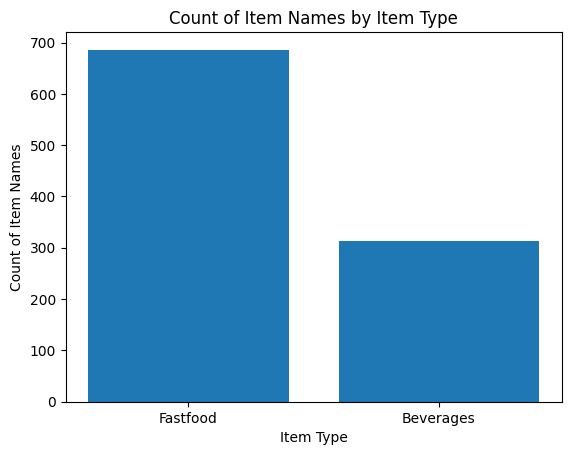

In [91]:
#plt.plot(kind='bar',x='item_type',y='item_name')
counts = df['item_type'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Count of Item Names by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Count of Item Names')
plt.show()

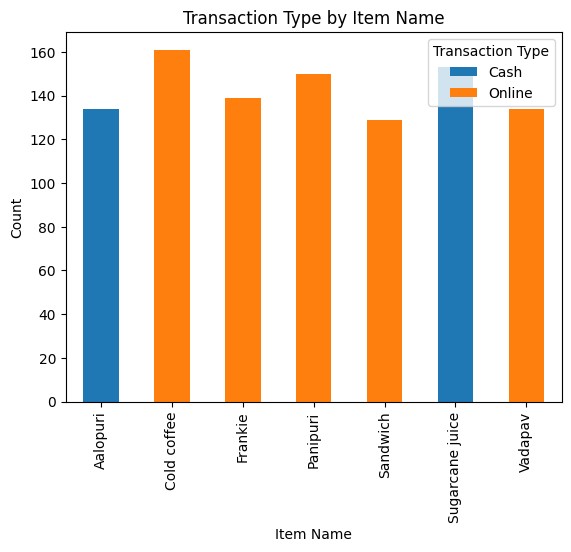

In [99]:

counts = df.groupby(['item_name', 'transaction_type']).size().unstack(fill_value=0)
#.unstack(fill_value=0): Converts the Series into a DataFrame, where the rows are indexed by 
# item_name and the columns represent each transaction_type. Missing values (where there are no 
# occurrences for a specific transaction_type and item_name) are filled with 0.
counts.plot(kind='bar')
plt.title('Transaction Type by Item Name')
plt.xlabel('Item Name')
plt.ylabel('Count')
plt.legend(title='Transaction Type')
plt.show()

In [94]:
mapping = {
    'Aalopuri': 'Cash',
    'Vadapav': 'Online',
    'Sugarcane juice': 'Cash',
    'Panipuri': 'Online',
    'Frankie': 'Online',
    'Sandwich':'Online',
    'Cold coffee':'Online'
}

df['transaction_type'] = df['item_name'].map(mapping).fillna(df['transaction_type'])

In [96]:
nan_rows = df[df['transaction_type'].isna()]
print(nan_rows)

Empty DataFrame
Columns: [order_id, date, item_name, item_type, item_price, quantity, transaction_amount, transaction_type, received_by, time_of_sale]
Index: []


In [97]:
df.isnull().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

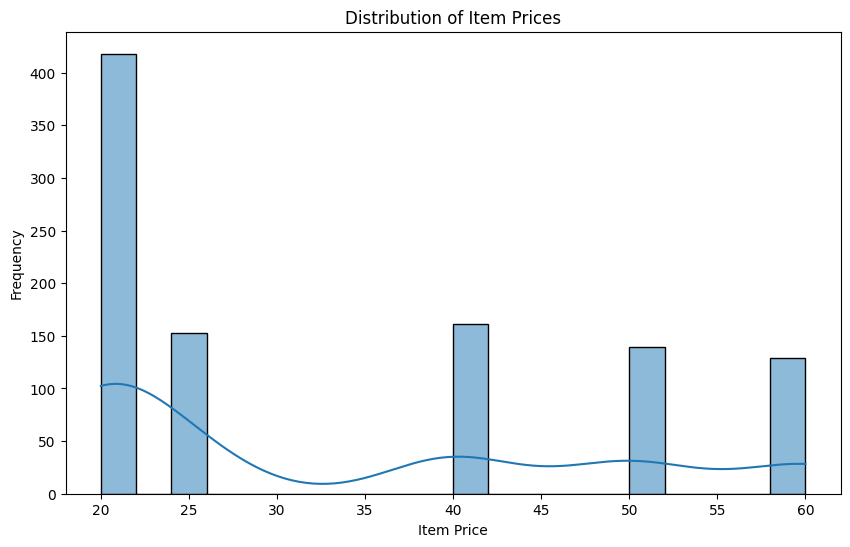

In [100]:
#to check the prices of item
plt.figure(figsize=(10, 6))
sns.histplot(df['item_price'], bins=20)
plt.title('Distribution of Item Prices')
plt.xlabel('Item Price')
plt.ylabel('Frequency')
plt.show()
#If a line is overlaid on the histogram, it typically represents the estimated probability density function.
#  This line helps visualize the distribution's shape more smoothly than the discrete bars of the histogram.

Numeric columns: Index(['order_id', 'item_price', 'quantity', 'transaction_amount'], dtype='object')


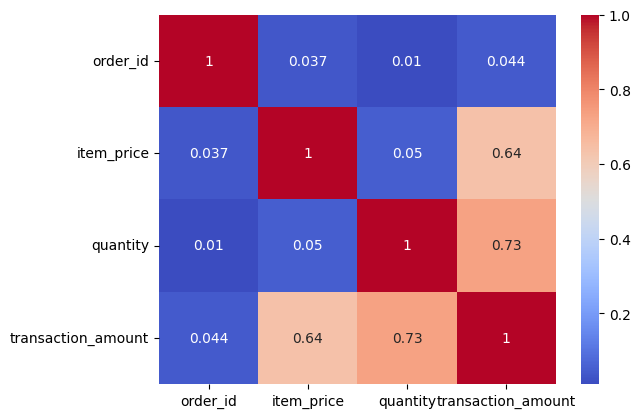

In [109]:
#correlation_matrix = df.corr()
#sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
#plt.show()
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numeric columns:", numeric_cols)
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True,cmap='coolwarm')
plt.show()

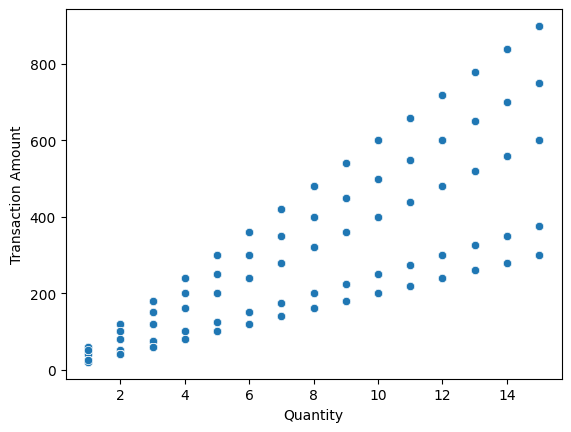

In [111]:
sns.scatterplot(data=df, x='quantity', y='transaction_amount')
plt.xlabel('Quantity')
plt.ylabel('Transaction Amount')
plt.show()

C:\Users\Sarvesh\AppData\Local\Temp\ipykernel_6516\635425917.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_data, x='quantity', y='transaction_amount', palette='viridis')


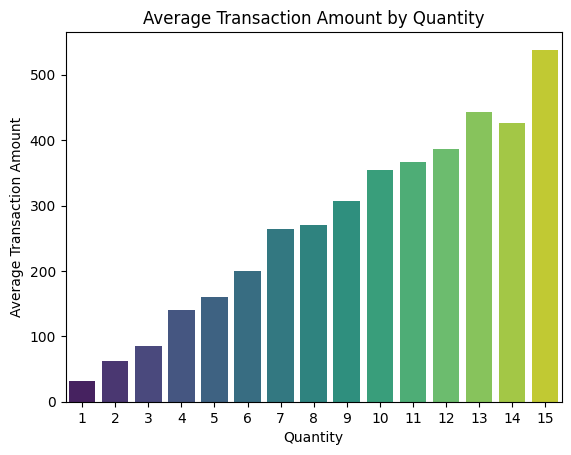

In [116]:
average_data = df.groupby('quantity')['transaction_amount'].mean().reset_index()
sns.barplot(data=average_data, x='quantity', y='transaction_amount', palette='viridis')
plt.title('Average Transaction Amount by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Average Transaction Amount')
plt.show()
#Reset index: This creates a new DataFrame with the results and resets the index,
# turning the grouped data back into a regular DataFrame.

C:\Users\Sarvesh\AppData\Local\Temp\ipykernel_6516\768153693.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='received_by', palette='viridis', order=df['received_by'].value_counts().index)


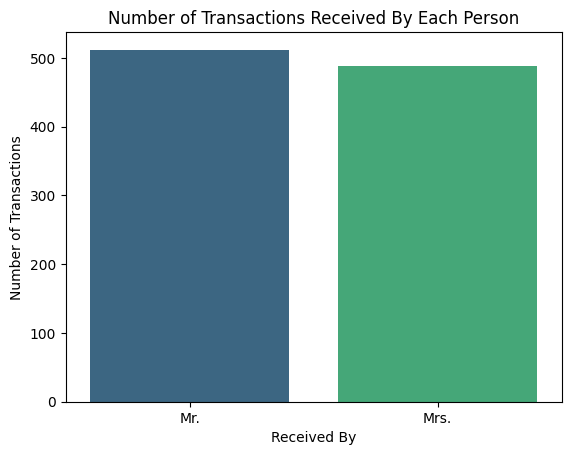

In [118]:
sns.countplot(data=df, x='received_by', palette='viridis', order=df['received_by'].value_counts().index)
plt.title('Number of Transactions Received By Each Person')
plt.xlabel('Received By')
plt.ylabel('Number of Transactions')
plt.show()

In [124]:
df['time_of_sale'].unique()

array(['Night', 'Afternoon', 'Evening', 'Morning', 'Midnight'],
      dtype=object)

C:\Users\Sarvesh\AppData\Local\Temp\ipykernel_6516\3975915464.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='time_of_sale', palette='coolwarm', order=df['time_of_sale'].value_counts().index)


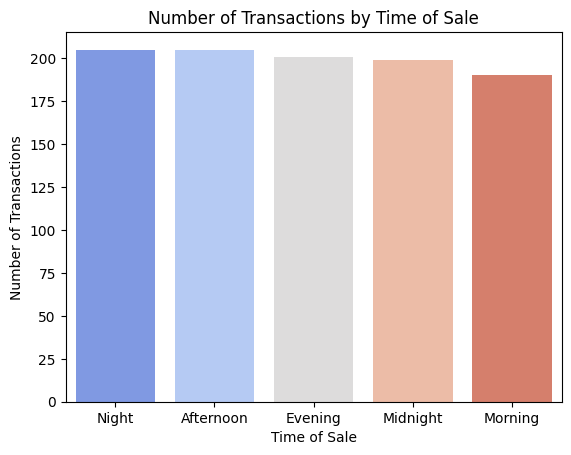

In [127]:
sns.countplot(data=df, x='time_of_sale', palette='coolwarm', order=df['time_of_sale'].value_counts().index)
plt.title('Number of Transactions by Time of Sale')
plt.xlabel('Time of Sale')
plt.ylabel('Number of Transactions')
plt.show()

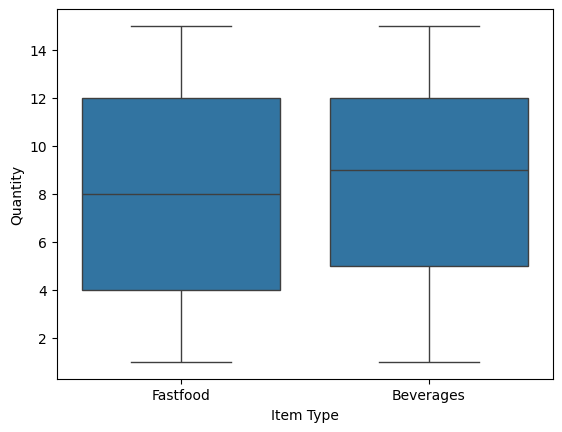

In [134]:
sns.boxplot(data=df, x='item_type', y='quantity')
plt.xlabel('Item Type')
plt.ylabel('Quantity')
plt.show()

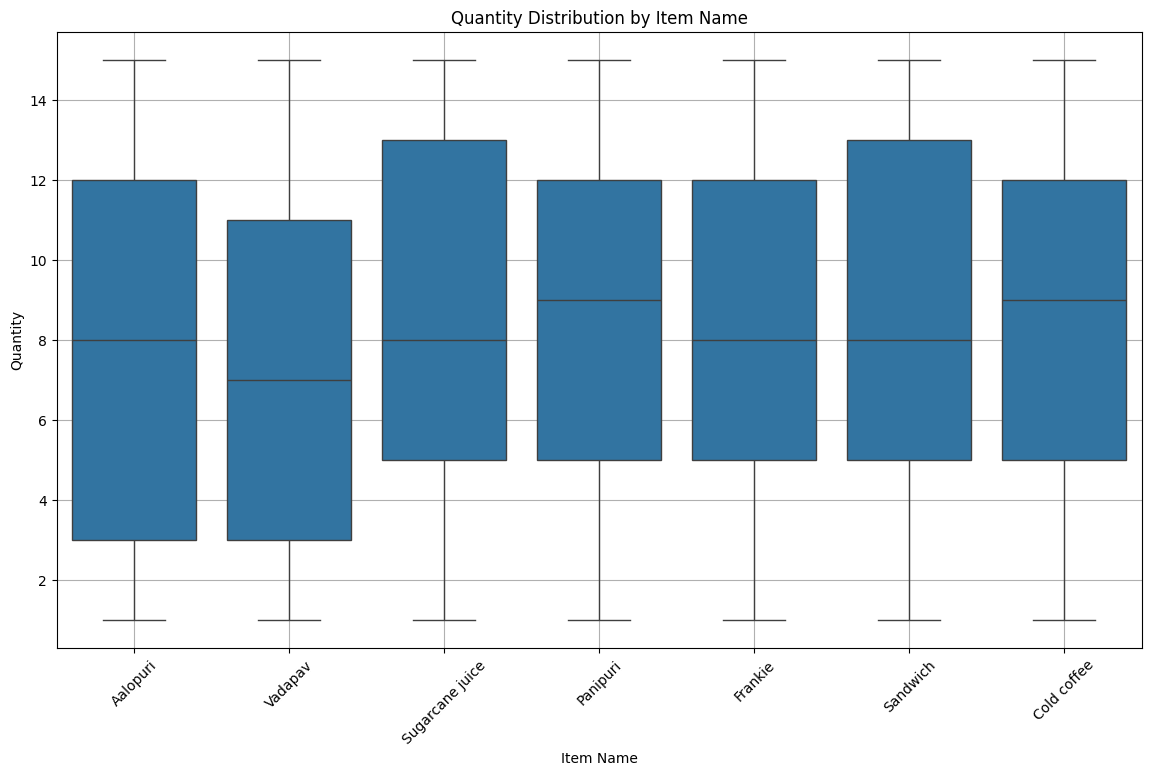

In [131]:
sns.boxplot(data=df, x='item_name', y='quantity')
plt.xlabel('Item Name')
plt.ylabel('Quantity')
plt.show()

C:\Users\Sarvesh\AppData\Local\Temp\ipykernel_6516\432923270.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= average_quantity, x='item_name', y='quantity', palette='coolwarm')


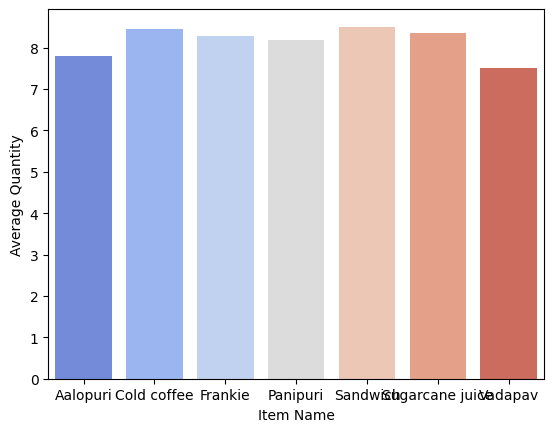

In [137]:
average_quantity = df.groupby('item_name')['quantity'].mean().reset_index()
sns.barplot(data= average_quantity, x='item_name', y='quantity', palette='coolwarm')
plt.xlabel('Item Name')
plt.ylabel('Average Quantity')
plt.show()